# Drug Consumption — Modèles Binaires de Confirmation (Étape 2)

**Modèle choisi : Régression Logistique**

Choix justifié par le contexte médical : les coefficients sont directement interprétables, chaque feature a un impact lisible et explicable au praticien. La perte de performance par rapport au Random Forest (~6 points de F1) est acceptable en échange d'une transparence totale sur les décisions.

**Input  :** `prepared_data.pkl` + `multiclass_model.pkl`

**Output :** `binary_models.pkl`

**Pipeline :**
```
prepared_data.pkl  ──→  nb_binary.ipynb  ──→  binary_models.pkl
multiclass_model.pkl ──↗                              ↓
                                                   app.py
```

## 0. Imports

In [20]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

BLUE  = '#1F4E79'; LBLUE = '#2E75B6'; GREEN = '#1D9E75'
ORANGE= '#E8A838'; RED   = '#E24B4A'; LGRAY = '#F2F2F2'
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

## 1. Import de prepared_data.pkl

In [21]:
with open('../DATA_MODELE/prepared_data.pkl', 'rb') as f:
    prepared = pickle.load(f)

datasets          = prepared['datasets']
X_raw             = prepared['X_raw']
FEATURE_COLS      = prepared['feature_cols']
TARGET_SUBSTANCES = prepared['target_substances']

TARGET_ILLICIT = [
    'cannabis', 'benzos', 'ecstasy', 'amphet', 'coke', 'lsd',
    'mushrooms', 'legalh', 'amyl', 'meth', 'ketamine', 'heroin', 'vsa'
]

FEATURE_LABELS = {
    'age': 'Âge', 'gender': 'Genre', 'education': 'Éducation',
    'country': 'Pays', 'ethnicity': 'Ethnicité',
    'nscore': 'Neuroticisme', 'escore': 'Extraversion', 'oscore': 'Ouverture',
    'ascore': 'Agréabilité', 'cscore': 'Conscienciosité',
    'impulsive': 'Impulsivité', 'ss': 'Sensation-Seeking',
    'alcohol_bin': 'Alcool', 'caff_bin': 'Caféine',
    'choc_bin': 'Chocolat', 'nicotine_bin': 'Nicotine',
}

SUBSTANCE_LABELS = {
    'cannabis': 'Cannabis', 'benzos': 'Benzodiazépines', 'ecstasy': 'Ecstasy',
    'amphet': 'Amphétamines', 'coke': 'Cocaïne', 'lsd': 'LSD',
    'mushrooms': 'Champignons', 'legalh': 'Legal Highs', 'amyl': 'Amyl',
    'meth': 'Méthamphétamine', 'ketamine': 'Kétamine',
    'heroin': 'Héroïne', 'vsa': 'Solvants'
}

print('✅ prepared_data.pkl chargé')
print(f'   Substances illicites : {TARGET_ILLICIT}')
print()
for s in TARGET_ILLICIT:
    d = datasets[s]
    print(f'  {s:<14} | stratégie={d["strategy"]:<15} | X={d["X"].shape} | class_weight={d["class_weight"]}')

✅ prepared_data.pkl chargé
   Substances illicites : ['cannabis', 'benzos', 'ecstasy', 'amphet', 'coke', 'lsd', 'mushrooms', 'legalh', 'amyl', 'meth', 'ketamine', 'heroin', 'vsa']

  cannabis       | stratégie=direct          | X=(1877, 16) | class_weight=None
  benzos         | stratégie=smote           | X=(2690, 16) | class_weight=None
  ecstasy        | stratégie=smote           | X=(2728, 16) | class_weight=None
  amphet         | stratégie=smote_weights   | X=(2888, 16) | class_weight=balanced
  coke           | stratégie=smote_weights   | X=(2926, 16) | class_weight=balanced
  lsd            | stratégie=smote_weights   | X=(3002, 16) | class_weight=balanced
  mushrooms      | stratégie=smote_weights   | X=(2898, 16) | class_weight=balanced
  legalh         | stratégie=smote           | X=(2632, 16) | class_weight=None
  amyl           | stratégie=smote_weights   | X=(3490, 16) | class_weight=balanced
  meth           | stratégie=smote_weights   | X=(3116, 16) | class_weight=bala

## 2. Pourquoi la Régression Logistique ?

Dans un contexte médical, **l'explicabilité prime sur la performance brute**. La régression logistique présente trois avantages décisifs :

- **Coefficients interprétables** : chaque feature a un coefficient β qui quantifie son impact sur la probabilité de consommation. Un médecin peut comprendre et valider la logique du modèle.
- **Odds ratios** : les coefficients exponentiés donnent des ratios de cotes directement utilisables en épidémiologie clinique.
- **Transparence totale** : contrairement au Random Forest (boîte noire), chaque prédiction individuelle est décomposable en contributions claires par feature.

## 3. Optimisation du paramètre C (régularisation)

Meilleur C : 1.0 (F1 = 0.850)



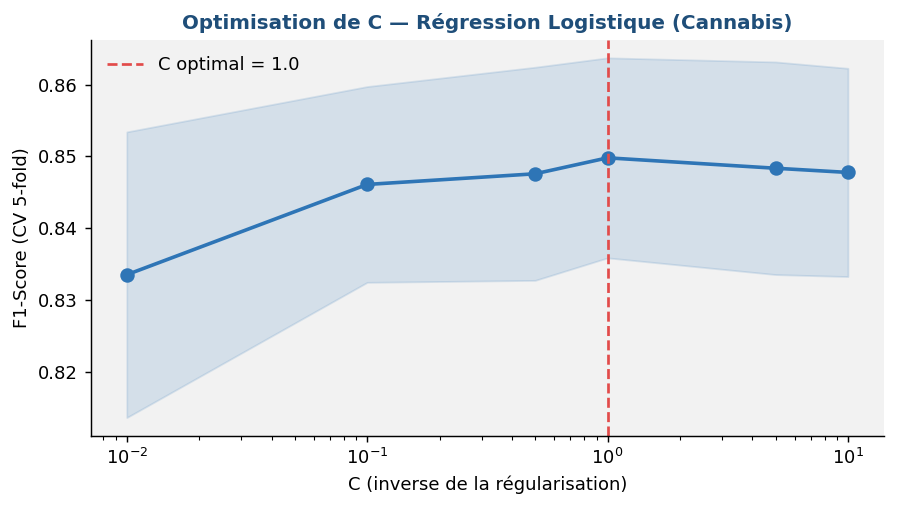

In [22]:
# GridSearch sur C pour la substance principale (cannabis)
# Le C optimal sera utilisé pour toutes les substances
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_can = datasets['cannabis']['X']
y_can = datasets['cannabis']['y']

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight=None),
    param_grid={'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]},
    cv=cv, scoring='f1', n_jobs=-1
)
grid.fit(X_can, y_can)

BEST_C = grid.best_params_['C']
print(f'Meilleur C : {BEST_C} (F1 = {grid.best_score_:.3f})')
print()

# Visualisation de l'impact de C
results_c = grid.cv_results_
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx([0.01,0.1,0.5,1.0,5.0,10.0], results_c['mean_test_score'],
            'o-', color=LBLUE, linewidth=2, markersize=7)
ax.fill_between([0.01,0.1,0.5,1.0,5.0,10.0],
                results_c['mean_test_score'] - results_c['std_test_score'],
                results_c['mean_test_score'] + results_c['std_test_score'],
                alpha=0.15, color=LBLUE)
ax.axvline(BEST_C, color=RED, linestyle='--', linewidth=1.5, label=f'C optimal = {BEST_C}')
ax.set_xlabel('C (inverse de la régularisation)', fontsize=10)
ax.set_ylabel('F1-Score (CV 5-fold)', fontsize=10)
ax.set_title('Optimisation de C — Régression Logistique (Cannabis)',
             fontweight='bold', color=BLUE, fontsize=11)
ax.legend(frameon=False)
ax.set_facecolor(LGRAY)
plt.tight_layout()
plt.show()

> **C'est quoi le paramètre C ?**  
> C est l'inverse du coefficient de régularisation. Un C faible = forte régularisation = modèle simple qui généralise mieux mais peut sous-apprendre. Un C élevé = faible régularisation = modèle qui colle plus aux données d'entraînement mais risque le surapprentissage.  
> On optimise sur le cannabis car c'est la substance la plus représentée — le C optimal trouvé ici sera appliqué à toutes les substances.

## 4. Entraînement — Un modèle logistique par substance

In [23]:
models  = {}
metrics = {}

print(f'{"Substance":<14} {"Stratégie":<16} {"F1":>6} {"Recall":>8} {"Précision":>10} {"ROC-AUC":>8}')
print('-' * 70)

for substance in TARGET_ILLICIT:
    X_r   = datasets[substance]['X']
    y_r   = datasets[substance]['y']
    cw    = datasets[substance]['class_weight']
    strat = datasets[substance]['strategy']

    lr = LogisticRegression(
        C            = BEST_C,
        max_iter     = 1000,
        random_state = 42,
        class_weight = cw,
    )
    lr.fit(X_r, y_r)
    models[substance] = lr

    y_pred  = cross_val_predict(lr, X_r, y_r, cv=cv)
    y_proba = cross_val_predict(lr, X_r, y_r, cv=cv, method='predict_proba')[:, 1]

    metrics[substance] = {
        'f1':           f1_score(y_r, y_pred, zero_division=0),
        'recall':       recall_score(y_r, y_pred, zero_division=0),
        'precision':    precision_score(y_r, y_pred, zero_division=0),
        'roc_auc':      roc_auc_score(y_r, y_proba),
        'coefficients': lr.coef_[0].tolist(),
        'intercept':    float(lr.intercept_[0]),
        'strategy':     strat,
        'label':        SUBSTANCE_LABELS[substance],
    }

    m = metrics[substance]
    print(f"{substance:<14} {strat:<16} {m['f1']:>6.3f} {m['recall']:>8.3f} "
          f"{m['precision']:>10.3f} {m['roc_auc']:>8.3f}")

print()
f1_mean  = np.mean([metrics[s]['f1']      for s in TARGET_ILLICIT])
rec_mean = np.mean([metrics[s]['recall']  for s in TARGET_ILLICIT])
auc_mean = np.mean([metrics[s]['roc_auc'] for s in TARGET_ILLICIT])
print(f'Moyennes — F1={f1_mean:.3f} | Recall={rec_mean:.3f} | AUC={auc_mean:.3f}')
print('✅ Entraînement terminé')

Substance      Stratégie            F1   Recall  Précision  ROC-AUC
----------------------------------------------------------------------
cannabis       direct            0.850    0.843      0.857    0.914
benzos         smote             0.730    0.740      0.721    0.796
ecstasy        smote             0.785    0.807      0.765    0.848
amphet         smote_weights     0.787    0.812      0.763    0.856
coke           smote_weights     0.763    0.802      0.727    0.824
lsd            smote_weights     0.845    0.877      0.815    0.899
mushrooms      smote_weights     0.824    0.856      0.793    0.883
legalh         smote             0.797    0.818      0.777    0.865
amyl           smote_weights     0.770    0.813      0.732    0.816
meth           smote_weights     0.783    0.816      0.752    0.845
ketamine       smote_weights     0.768    0.814      0.727    0.813
heroin         smote_weights     0.817    0.868      0.772    0.868
vsa            smote_weights     0.800    0.8

> **Pourquoi `class_weight` vient de prepared_data.pkl ?**  
> La stratégie de rééquilibrage a été définie une fois pour toutes dans `nb_preparation.ipynb`. On la réutilise ici directement pour rester cohérent avec le reste du pipeline. Pour les substances très déséquilibrées (SMOTE+W), le `class_weight='balanced'` pénalise davantage les erreurs sur la classe minoritaire — le modèle apprend à ne pas ignorer les consommateurs rares.

## 5. Coefficients — L'atout explicabilité

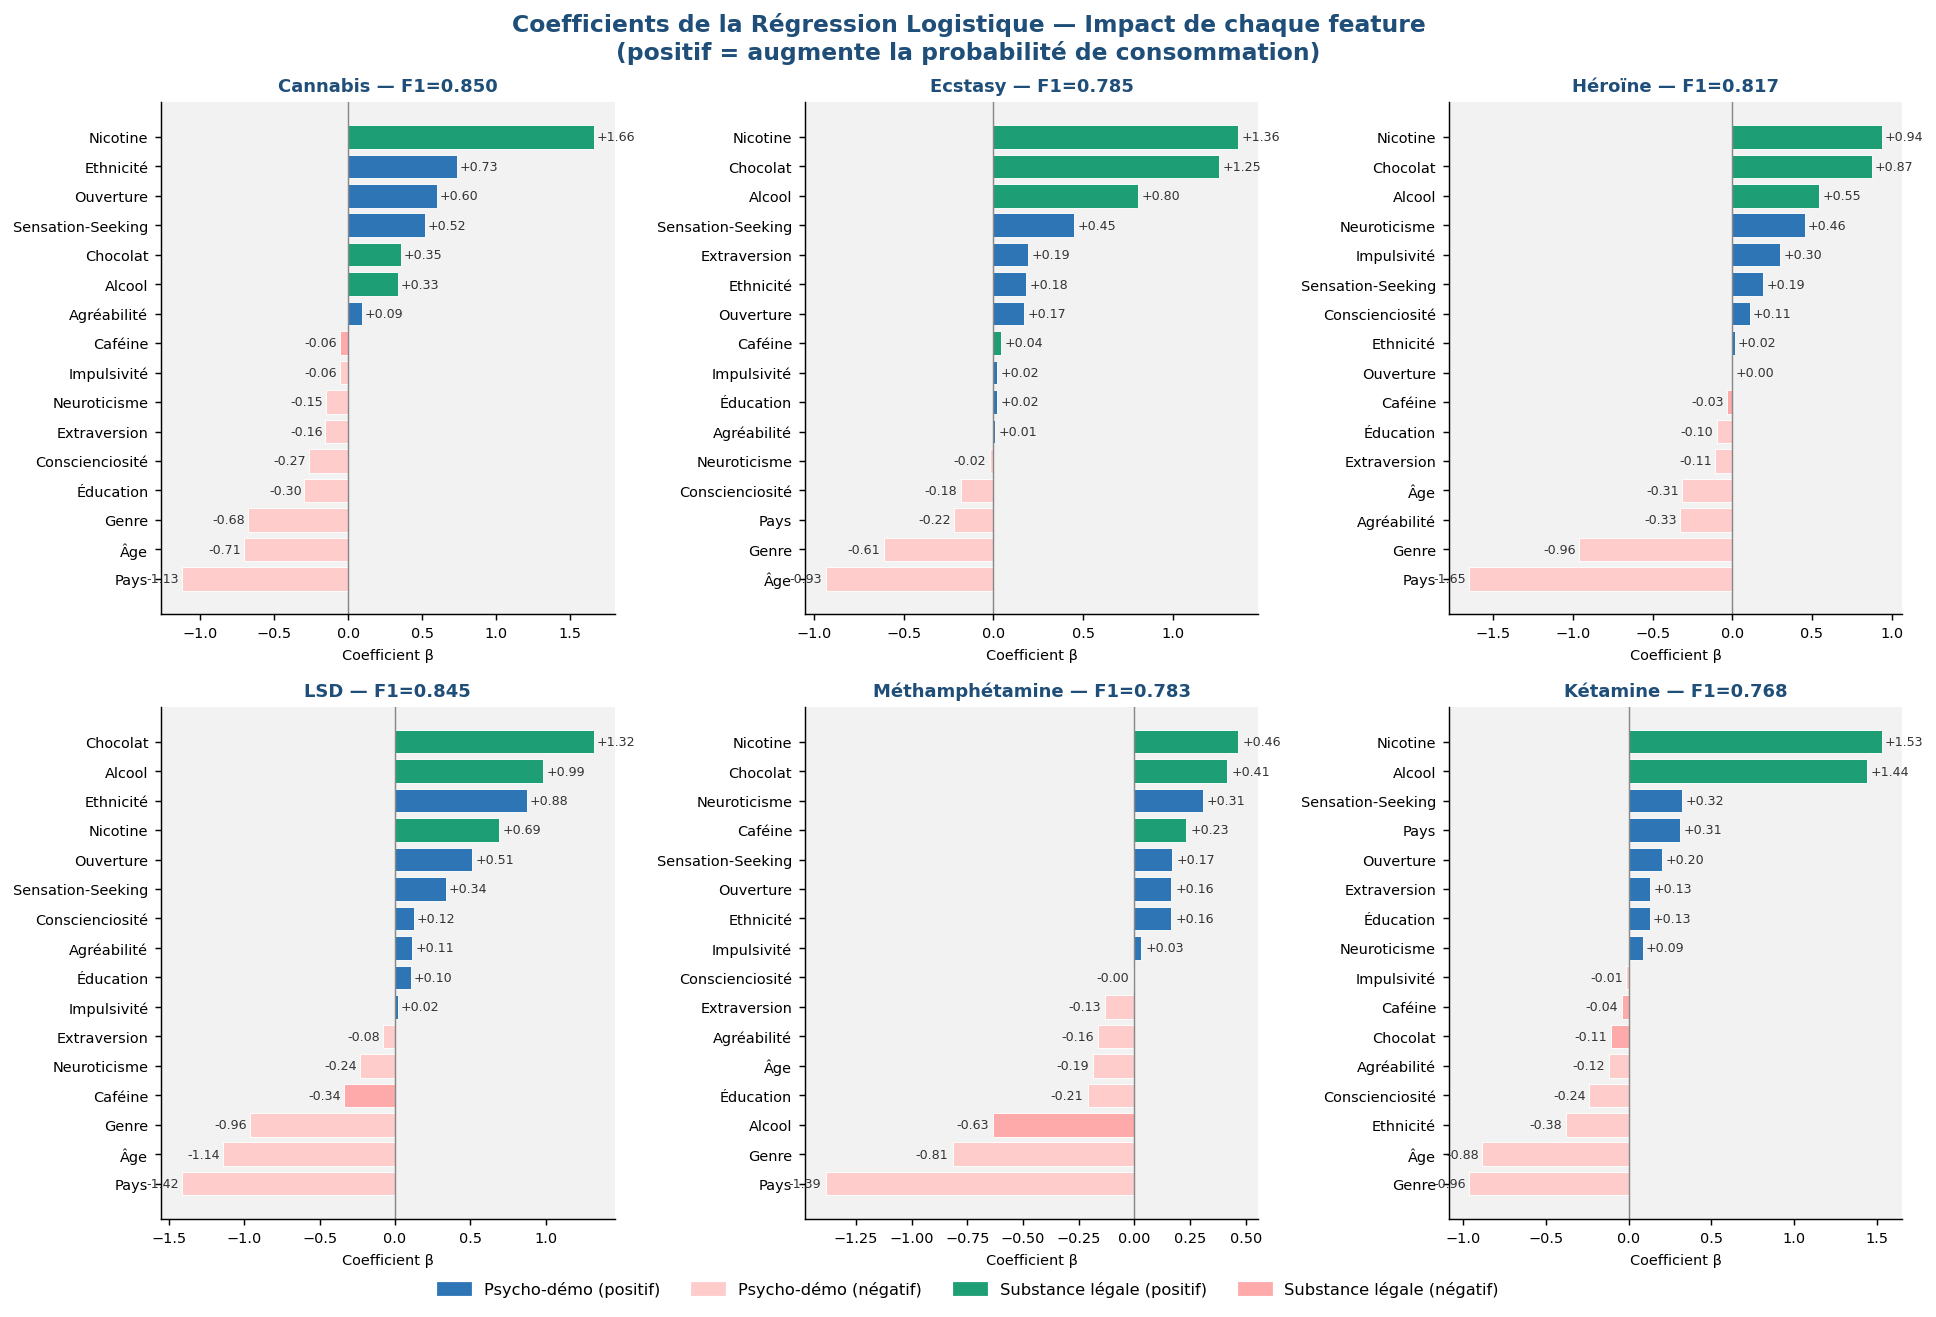

In [24]:
# Visualisation des coefficients pour 6 substances clés
substances_focus = ['cannabis', 'ecstasy', 'heroin', 'lsd', 'meth', 'ketamine']
labels_feat      = [FEATURE_LABELS[c] for c in FEATURE_COLS]
is_legal         = ['bin' in c for c in FEATURE_COLS]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Coefficients de la Régression Logistique — Impact de chaque feature\n'
             '(positif = augmente la probabilité de consommation)',
             fontweight='bold', color=BLUE, fontsize=13)
axes = axes.flatten()

for i, substance in enumerate(substances_focus):
    coefs    = np.array(metrics[substance]['coefficients'])
    idx_sort = np.argsort(coefs)
    colors   = []
    for j in idx_sort:
        if coefs[j] > 0:
            colors.append(GREEN if is_legal[j] else LBLUE)
        else:
            colors.append('#ffaaaa' if is_legal[j] else '#ffcccc')

    ax = axes[i]
    bars = ax.barh(np.array(labels_feat)[idx_sort], coefs[idx_sort],
                   color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#888', linewidth=0.8, linestyle='-')

    # Annotation des valeurs
    for bar, j in zip(bars, idx_sort):
        val = coefs[j]
        x_pos = val + 0.02 if val >= 0 else val - 0.02
        ha    = 'left' if val >= 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{val:+.2f}', va='center', fontsize=7, color='#333', ha=ha)

    ax.set_title(
        f'{SUBSTANCE_LABELS.get(substance, substance)} — F1={metrics[substance]["f1"]:.3f}',
        fontweight='bold', color=BLUE, fontsize=10
    )
    ax.set_xlabel('Coefficient β', fontsize=8)
    ax.set_facecolor(LGRAY)
    ax.tick_params(labelsize=8)

p1 = mpatches.Patch(color=LBLUE,    label='Psycho-démo (positif)')
p2 = mpatches.Patch(color='#ffcccc',label='Psycho-démo (négatif)')
p3 = mpatches.Patch(color=GREEN,    label='Substance légale (positif)')
p4 = mpatches.Patch(color='#ffaaaa',label='Substance légale (négatif)')
fig.legend(handles=[p1,p2,p3,p4], frameon=False, fontsize=9,
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

> **Pourquoi les coefficients sont meilleurs que les feature importances ?**  
> Les feature importances d'un Random Forest disent "cette variable compte", mais pas dans quel sens.  
> Les coefficients β de la régression logistique disent **exactement** : un coefficient positif augmente la probabilité de consommation, un négatif la diminue, et la magnitude indique l'intensité.  
> Par exemple, un coefficient β = +0.8 pour le Sensation-Seeking sur l'ecstasy signifie : "pour chaque augmentation d'1 point de SS, la log-odds de consommer de l'ecstasy augmente de 0.8" — c'est un langage épidémiologique standard, compréhensible par un médecin.

## 6. Odds Ratios — Traduction clinique des coefficients

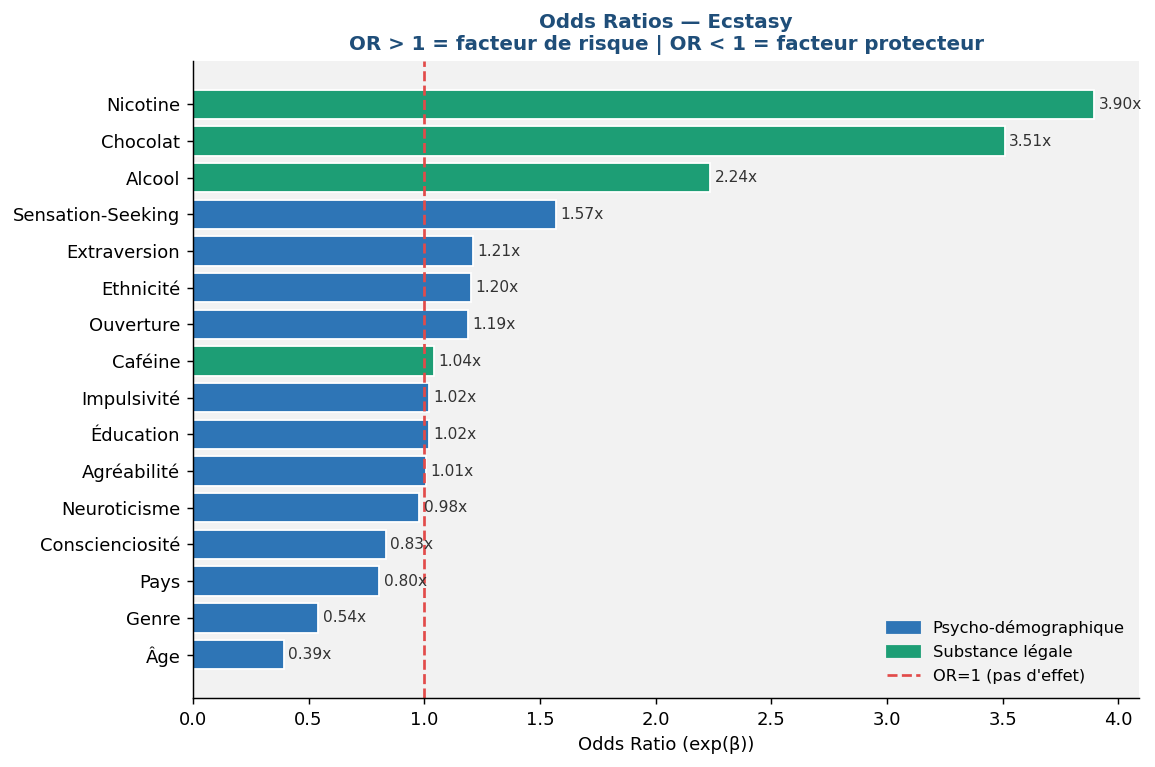

Odds Ratios — Ecstasy :
Feature                      OR Interprétation
-----------------------------------------------------------------
Nicotine                  3.896  Facteur de risque (+290%)
Chocolat                  3.508  Facteur de risque (+251%)
Alcool                    2.236  Facteur de risque (+124%)
Sensation-Seeking         1.567  Facteur de risque (+57%)
Extraversion              1.210  Effet neutre
Ethnicité                 1.200  Effet neutre
Ouverture                 1.189  Effet neutre
Caféine                   1.042  Effet neutre
Impulsivité               1.021  Effet neutre
Éducation                 1.018  Effet neutre
Agréabilité               1.007  Effet neutre
Neuroticisme              0.979  Effet neutre
Conscienciosité           0.834  Effet neutre
Pays                      0.805  Effet neutre
Genre                     0.543  Facteur protecteur (−46%)
Âge                       0.393  Facteur protecteur (−61%)


In [25]:
# Odds ratios = exp(coefficients) — standard en épidémiologie
substance_or = 'ecstasy'  # Exemple sur l'ecstasy
coefs        = np.array(metrics[substance_or]['coefficients'])
odds_ratios  = np.exp(coefs)
idx_sort     = np.argsort(odds_ratios)

fig, ax = plt.subplots(figsize=(9, 6))
colors_or = [GREEN if is_legal[j] else LBLUE for j in idx_sort]
bars = ax.barh(np.array(labels_feat)[idx_sort], odds_ratios[idx_sort],
               color=colors_or, edgecolor='white')
ax.axvline(1.0, color=RED, linewidth=1.5, linestyle='--', label='OR=1 (pas d\'effet)')

for bar, j in zip(bars, idx_sort):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{odds_ratios[j]:.2f}x', va='center', fontsize=8.5, color='#333')

ax.set_xlabel('Odds Ratio (exp(β))', fontsize=10)
ax.set_title(f'Odds Ratios — {SUBSTANCE_LABELS[substance_or]}\n'
             f'OR > 1 = facteur de risque | OR < 1 = facteur protecteur',
             fontweight='bold', color=BLUE, fontsize=11)
ax.set_facecolor(LGRAY)
ax.legend(frameon=False)
p1 = mpatches.Patch(color=LBLUE, label='Psycho-démographique')
p2 = mpatches.Patch(color=GREEN, label='Substance légale')
ax.legend(handles=[p1,p2] + ax.get_lines()[:1], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(f'Odds Ratios — {SUBSTANCE_LABELS[substance_or]} :')
print(f'{"Feature":<22} {"OR":>8} {"Interprétation"}')
print('-' * 65)
for j in np.argsort(odds_ratios)[::-1]:
    or_val = odds_ratios[j]
    feat   = FEATURE_LABELS[FEATURE_COLS[j]]
    if or_val > 1.3:
        interp = f'Facteur de risque (+{(or_val-1)*100:.0f}%)'
    elif or_val < 0.77:
        interp = f'Facteur protecteur (−{(1-or_val)*100:.0f}%)'
    else:
        interp = 'Effet neutre'
    print(f'{feat:<22} {or_val:>8.3f}  {interp}')

> **Pourquoi les odds ratios ?**  
> C'est le langage standard de l'épidémiologie clinique. Un OR = 2.5 pour le Sensation-Seeking signifie : "les individus avec un SS élevé ont 2.5 fois plus de chances d'être consommateurs d'ecstasy que ceux avec un SS faible".  
> OR > 1 = facteur de risque. OR < 1 = facteur protecteur. OR = 1 = pas d'effet.  
> C'est directement compréhensible par un médecin ou un addictologue — c'est l'argument clé pour justifier la régression logistique dans ce contexte.

## 7. Simulation — Pipeline complet multi-classe → binaire

In [26]:
with open('../MODELE_SAVE/multiclass_model.pkl', 'rb') as f:
    mc_data  = pickle.load(f)

rf_multi = mc_data['model']
classes  = mc_data['classes']

# Profil Marc — 28 ans, impulsif, SS élevé, fumeur
profil_marc = np.array([[
    -0.07854,  0.48246, -0.61113,  0.96082, -0.31685,
     0.50,    -0.20,    1.80,     -0.60,    -1.20,
     1.50,     2.10,    1, 1, 1, 1
]])

# Étape 1 : Multi-classe → top 3
probas_multi    = rf_multi.predict_proba(profil_marc)[0]
top3_idx        = np.argsort(probas_multi)[::-1][:3]
top3_substances = [classes[i] for i in top3_idx]
top3_probas     = [probas_multi[i] for i in top3_idx]

print('━━━ ÉTAPE 1 — MULTI-CLASSE ━━━')
for rank, (sub, prob) in enumerate(zip(top3_substances, top3_probas), 1):
    print(f'  #{rank} {SUBSTANCE_LABELS.get(sub, sub):<22} {prob*100:.1f}%')

# Étape 2 : Binaire (Régression Logistique) → confirmation
print()
print('━━━ ÉTAPE 2 — RÉGRESSION LOGISTIQUE ━━━')

results = []
for sub, proba_mc in zip(top3_substances, top3_probas):
    if sub not in models:
        continue
    proba_bin      = models[sub].predict_proba(profil_marc)[0][1]
    coefs          = np.array(metrics[sub]['coefficients'])
    top_feat_idx   = np.argmax(np.abs(coefs))  # feature avec le plus grand |coefficient|
    top_feat       = FEATURE_LABELS[FEATURE_COLS[top_feat_idx]]
    top_coef       = coefs[top_feat_idx]
    score_combined = 0.4 * proba_mc + 0.6 * proba_bin

    results.append({
        'substance':      sub,
        'label':          SUBSTANCE_LABELS.get(sub, sub),
        'proba_multi':    proba_mc,
        'proba_binary':   proba_bin,
        'score_combined': score_combined,
        'top_feature':    top_feat,
        'top_coef':       top_coef,
    })
    print(f'  {SUBSTANCE_LABELS.get(sub, sub):<22} '
          f'MC={proba_mc*100:.0f}%  LR={proba_bin*100:.0f}%  '
          f'Combiné={score_combined*100:.0f}%  '
          f'→ [{top_feat} β={top_coef:+.2f}]')

# Verdict
results.sort(key=lambda r: r['score_combined'], reverse=True)
verdict = results[0]
print()
print('━━━ VERDICT FINAL ━━━')
print(f'🔴 Substance la plus probable : {verdict["label"]}')
print(f'   Score combiné             : {verdict["score_combined"]*100:.1f}%')
print(f'   Facteur déterminant       : {verdict["top_feature"]} (β={verdict["top_coef"]:+.2f})')

━━━ ÉTAPE 1 — MULTI-CLASSE ━━━
  #1 Cannabis               38.5%
  #2 Méthamphétamine        18.0%
  #3 Benzodiazépines        13.0%

━━━ ÉTAPE 2 — RÉGRESSION LOGISTIQUE ━━━
  Cannabis               MC=38%  LR=93%  Combiné=71%  → [Nicotine β=+1.66]
  Méthamphétamine        MC=18%  LR=32%  Combiné=27%  → [Pays β=-1.39]
  Benzodiazépines        MC=13%  LR=57%  Combiné=39%  → [Ethnicité β=+1.15]

━━━ VERDICT FINAL ━━━
🔴 Substance la plus probable : Cannabis
   Score combiné             : 71.3%
   Facteur déterminant       : Nicotine (β=+1.66)


> **Pourquoi combiner multi-classe et binaire ?**  
> Le multi-classe (Random Forest) réduit le champ des possibles en identifiant les substances les plus probables dans l'espace global. La régression logistique affine ensuite avec une probabilité précise et surtout un coefficient explicatif.  
> Le score combiné (40% MC + 60% LR) donne plus de poids au modèle binaire car il est plus précis sur la substance spécifique.  
> Le coefficient β affiché dans le verdict est l'explication directe : "c'est principalement le Sensation-Seeking élevé qui oriente vers l'ecstasy".

## 8. Export — binary_models.pkl

In [27]:
with open('../MODELE_SAVE/binary_models.pkl', 'wb') as f:
    pickle.dump({
        'models':           models,
        'metrics':          metrics,
        'feature_cols':     FEATURE_COLS,
        'feature_labels':   FEATURE_LABELS,
        'substance_labels': SUBSTANCE_LABELS,
        'target_illicit':   TARGET_ILLICIT,
        'model_type':       'LogisticRegression',
        'best_C':           BEST_C,
    }, f)

f1_mean  = np.mean([metrics[s]['f1']      for s in TARGET_ILLICIT])
rec_mean = np.mean([metrics[s]['recall']  for s in TARGET_ILLICIT])
auc_mean = np.mean([metrics[s]['roc_auc'] for s in TARGET_ILLICIT])

print('✅ binary_models.pkl exporté')
print(f'   Modèle      : Régression Logistique (C={BEST_C})')
print(f'   Substances  : {len(models)}')
print(f'   F1 moyen    : {f1_mean:.3f}')
print(f'   Recall moyen: {rec_mean:.3f}')
print(f'   AUC moyen   : {auc_mean:.3f}')
print()
print('Pipeline complet :')
print('  nb_preparation.ipynb  →  prepared_data.pkl')
print('  nb_multiclass.ipynb   →  multiclass_model.pkl  (Random Forest)')
print('  nb_binary.ipynb       →  binary_models.pkl     (Régression Logistique)')
print('  app.py                →  Streamlit')

✅ binary_models.pkl exporté
   Modèle      : Régression Logistique (C=1.0)
   Substances  : 13
   F1 moyen    : 0.794
   Recall moyen: 0.824
   AUC moyen   : 0.852

Pipeline complet :
  nb_preparation.ipynb  →  prepared_data.pkl
  nb_multiclass.ipynb   →  multiclass_model.pkl  (Random Forest)
  nb_binary.ipynb       →  binary_models.pkl     (Régression Logistique)
  app.py                →  Streamlit
